# Triple Products

Cycle-test circuits for measuring the real parts of triple products `Re tr(σ_i σ_j σ_k)` for WH orbit states in `cirq_sic`.

In [1]:
from math import comb
import numpy as np
import cirq

from cirq_sic import *

In [2]:
d = 4
phi = load_sic_fiducial(d)
prepare_fiducial = ansatz_circuit(phi)

triples = [(0, 0), (1, 0), (2, 1)]
prepare_states = [
    (lambda qubits, a1=a1, a2=a2: wh_state(qubits, prepare_fiducial, a1, a2))
    for a1, a2 in triples
]

qubits = cirq.LineQubit.range(1 + 3 * int(np.log2(d)))
control_qubit = qubits[0]
n = int(np.log2(d))
register1 = qubits[1 : 1 + n]
register2 = qubits[1 + n : 1 + 2 * n]
register3 = qubits[1 + 2 * n : 1 + 3 * n]

circuit = triple_product_measurement_circuit(
    control_qubit,
    register1,
    register2,
    register3,
    prepare_states[0],
    prepare_states[1],
    prepare_states[2],
)

probabilities = exact_simulation(circuit)
measured_value = real_triple_product_from_probabilities(probabilities)

orbit_states = wh_frame(phi).T
orbit_projectors = [np.outer(psi, psi.conj()) for psi in orbit_states]
indices = [a1 * d + a2 for a1, a2 in triples]
expected_value = np.trace(
    orbit_projectors[indices[0]]
    @ orbit_projectors[indices[1]]
    @ orbit_projectors[indices[2]]
).real

print('Measured:', measured_value)
print('Expected:', expected_value)
print('Close:', np.allclose(measured_value, expected_value))

circuit

Measured: -0.029247046
Expected: -0.029247125175112895
Close: True


┌──┐                                                                 ┌───────┐              ┌──┐                                                                 ┌───────┐              ┌──┐                                                                 ┌───────┐              ┌──┐                                                                 ┌───────┐
0: ───H────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────X────────@────X─────────────@───T^-1───X───@───T──────X───@───X^0.5───@───@───X────@──────────X───@───────X─────────────@───T^-1───X───@───T──────X───@───X^0.5───@───@───X────@──────────X───@───────X─────────────@───T^-1───X───@───T──────X───@───X^0.5───@───@───X────@──────────X───@───────X─────────────@───T^-1───X───@───T──────X───@───X^0.5───@───@───X────@──────────H───M('result')───
                                                                                                                                                           │        │    │             │          │   │          │   │           │   │   │    │          │   │       │             │          │   │          │   │           │   │   │    │          │   │       │             │          │   │          │   │           │   │   │    │          │   │       │             │          │   │          │   │           │   │   │    │
1: ───Rz(1.63π)────Ry(0.566π)───Rz(0.133π)───@─────────────────@─────────────────@─────────────────@───H───@───────────────×───×─────────@────────H────────@────────X────┼T────────────┼──────────@───┼──────────@───┼───────────X───┼───@────┼X^-0.5────┼───┼───────┼─────────────┼──────────┼───┼──────────┼───┼───────────┼───┼───┼────┼──────────@───X───────┼T────────────┼──────────@───┼──────────@───┼───────────X───┼───@────┼X^-0.5────┼───┼───────┼─────────────┼──────────┼───┼──────────┼───┼───────────┼───┼───┼────┼────────────────────────────
                                             │                 │                 │                 │       │               │   │         │                               │             │              │              │               │        │          │   │       │             │          │   │          │   │           │   │   │    │                      │             │              │              │               │        │          │   │       │             │          │   │          │   │           │   │   │    │
2: ───Ry(0.636π)─────────────────────────────X───Ry(-0.197π)───X───Rz(-0.338π)───X───Rz(-0.633π)───X───────@^0.5───H───────×───×───H─────@^-0.5──────────────────────────┼─────────────┼──────────────┼──────────────┼───────────────┼────────┼──────────@───X───────┼T────────────┼──────────@───┼──────────@───┼───────────X───┼───@────┼X^-0.5────────────────┼─────────────┼──────────────┼──────────────┼───────────────┼────────┼──────────@───X───────┼T────────────┼──────────@───┼──────────@───┼───────────X───┼───@────┼X^-0.5──────────────────────
                                                                                                                                                                         │             │              │              │               │        │                      │             │              │              │               │        │                      │             │              │              │               │        │                      │             │              │              │               │        │
3: ───Rz(1.63π)────Ry(0.566π)───Rz(0.133π)───@─────────────────@─────────────────@─────────────────@───H───@───────────────×───Z───×──────────────@────────H─────────────┼─────────────┼──────────────┼──────────────┼───────────────┼────────┼──────────────────────┼─────────────┼──────────────┼──────────────┼───────────────┼────────┼──────────────────────@─────H───T───X───T──────────X───T^-1───────X───T^-1────────X────────X──────────H───S^-1────┼─────────────┼─────

In [82]:
d = 2
phi = load_sic_fiducial(d)

task = CharacterizeWHTripleProductsTask(
    dataset_id='notebook',
    processor_id='willow_pink',
    run_type='clean',
    qubits=get_triple_product_qubits(d),
    n_shots=500,
    optimizer='cirq',
    d=d,
    fiducial=phi,
    fiducial_description='numerical_sic',
)

tensor_exact = exactify(task)['T']
orbit_states = wh_frame(phi).T
orbit_projectors = [np.outer(psi, psi.conj()) for psi in orbit_states]
tensor_numpy = np.array([
    [[np.trace(rho_i @ rho_j @ rho_k).real for rho_k in orbit_projectors]
     for rho_j in orbit_projectors]
    for rho_i in orbit_projectors
])

print('Unique circuits:', len(task.make_circuits()), 'of', comb(d**2 + 2, 3))
print('Tensor shape:', tensor_exact.shape)
print('Symmetric:', np.allclose(tensor_exact, np.transpose(tensor_exact, (1, 0, 2))))
print('Matches NumPy:', np.allclose(tensor_exact, tensor_numpy))

base_dir = 'cirq_sic/notebooks/tmp_triple_products'
run_sky_ground_task(task, base_dir=base_dir)
results = load_results(task, base_dir=base_dir)
T = np.array(results["processed_data"]["T"]); T

Unique circuits: 20 of 20
Tensor shape: (4, 4, 4)
Symmetric: True
Matches NumPy: False
2026-06-24 18:31:18 [INFO] notebook/d2/CharacterizeWHTripleProductsTask/numerical_sic/cirq_clean_n500_willow_pink_q7_2-4_2-5_2-6_2: Task already exists. Skipping.


array([[[ 1.   ,  0.316,  0.352,  0.376],
        [ 0.316,  0.304,  0.012,  0.028],
        [ 0.352,  0.012,  0.38 , -0.028],
        [ 0.376,  0.028, -0.028,  0.336]],

       [[ 0.316,  0.304,  0.012,  0.028],
        [ 0.304,  1.   ,  0.288,  0.312],
        [ 0.012,  0.288,  0.356,  0.016],
        [ 0.028,  0.312,  0.016,  0.344]],

       [[ 0.352,  0.012,  0.38 , -0.028],
        [ 0.012,  0.288,  0.356,  0.016],
        [ 0.38 ,  0.356,  1.   ,  0.34 ],
        [-0.028,  0.016,  0.34 ,  0.328]],

       [[ 0.376,  0.028, -0.028,  0.336],
        [ 0.028,  0.312,  0.016,  0.344],
        [-0.028,  0.016,  0.34 ,  0.328],
        [ 0.336,  0.344,  0.328,  1.   ]]])

In [83]:
def sample_valid_probabilities(N, T):
    n = T.shape[0]
    d = int(np.sqrt(n))

    P = np.sum(T, axis=0)/d**2
    Phi = np.linalg.pinv(P)

    rng = np.random.default_rng()
    p = rng.dirichlet(np.ones(n), size=N).T
    L = np.einsum("ijk,kl->lij", T, Phi @ p)
    valid = np.all(np.linalg.eigvals(L)>=0, axis=1)
    valid_p = p.T[valid]
    return valid_p

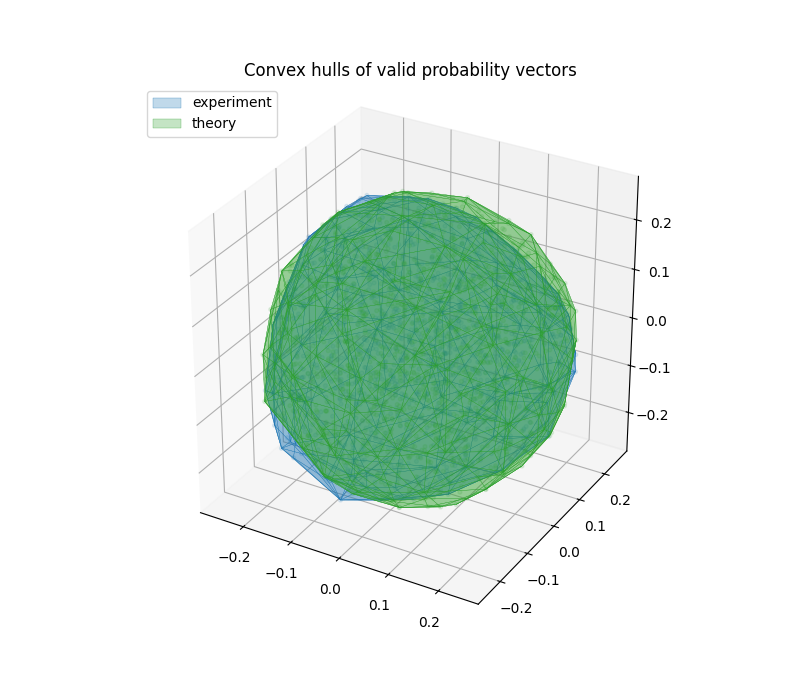

In [92]:
%matplotlib widget
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import ConvexHull

def _simplex_projection_basis():
    basis = np.array([
        [1, -1, 0, 0],
        [1, 1, -2, 0],
        [1, 1, 1, -3],
    ], dtype=float)
    basis /= np.linalg.norm(basis, axis=1, keepdims=True)
    return basis

def project_probability_vectors_to_3d(probabilities):
    probabilities = np.asarray(probabilities, dtype=float)
    if probabilities.ndim != 2 or probabilities.shape[1] != 4:
        raise ValueError('Expected an array of shape (n_points, 4).')

    center = np.ones(4) / 4
    basis = _simplex_projection_basis()
    return (probabilities - center) @ basis.T

def _set_equal_3d_axes(ax, points):
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    center = (mins + maxs) / 2
    radius = np.max(maxs - mins) / 2
    if radius == 0:
        radius = 1.0

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_box_aspect((1, 1, 1))

def plot_valid_probability_hulls(
    valid_ps,
    *,
    colors=None,
    labels=None,
    alpha=0.28,
    max_hull_points=1500,
    seed=0,
):
    if colors is None:
        colors = [f'C{i}' for i in range(len(valid_ps))]
    if labels is None:
        labels = [f'set {i + 1}' for i in range(len(valid_ps))]

    rng = np.random.default_rng(seed)
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    all_projected = []
    legend_handles = []

    for valid_p, color, label in zip(valid_ps, colors, labels):
        projected = project_probability_vectors_to_3d(valid_p)
        projected = np.unique(np.round(projected, decimals=10), axis=0)

        if len(projected) > max_hull_points:
            indices = rng.choice(len(projected), size=max_hull_points, replace=False)
            projected = projected[indices]

        all_projected.append(projected)
        ax.scatter(projected[:, 0], projected[:, 1], projected[:, 2], s=8, alpha=0.12, color=color)

        if len(projected) >= 4:
            hull = ConvexHull(projected)
            faces = [projected[simplex] for simplex in hull.simplices]
            poly = Poly3DCollection(
                faces,
                facecolor=color,
                edgecolor=color,
                linewidth=0.2,
                alpha=alpha,
            )
            ax.add_collection3d(poly)
            legend_handles.append(poly)
        else:
            handle = ax.scatter([], [], [], color=color, label=label)
            legend_handles.append(handle)

    stacked = np.vstack(all_projected)
    _set_equal_3d_axes(ax, stacked)
    ax.set_title('Convex hulls of valid probability vectors')
    #ax.set_xlabel('u1')
    #ax.set_ylabel('u2')
    #ax.set_zlabel('u3')
    ax.legend(legend_handles, labels, loc='upper left')
    plt.show()

N = 100000
valid_p = sample_valid_probabilities(N, T)
valid_p_exact = sample_valid_probabilities(N, tensor_exact)

plot_valid_probability_hulls(
    [valid_p, valid_p_exact],
    colors=['C0', 'C2'],
    labels=['experiment', 'theory'],
)